# Resumo do Código implementado

Este notebook implementa o algoritmo de **Dijkstra** seguindo a mesma sequência didática dos slides: primeiro o grafo ponderado é modelado em **lista de adjacência**, depois são criadas as rotinas de **inicialização**, **extração do vértice com menor distância**, **relaxamento de arestas**, **laço principal do algoritmo** e, por fim, a **reconstrução do caminho mínimo**.

A execução usa o grafo do slide e calcula o menor caminho de **`a` até `e`**, além de registrar as principais atualizações de distância para facilitar a leitura do passo a passo. Sempre que ajuda no entendimento, a explicação é complementada com visualização em **SVG/HTML**.

## Estrutura das células do notebook

1. Resumo do notebook e organização das células.
2. Explicação da modelagem do grafo e definição da entrada.
3. Código de importações e do grafo exemplo.
4. Explicação da visualização didática.
5. Código de plotagem em SVG.
6. Explicação da inicialização do algoritmo.
7. Código de inicialização do Dijkstra.
8. Explicação da extração do mínimo.
9. Código da função de extração do mínimo.
10. Explicação do relaxamento de arestas.
11. Código da função de relaxamento.
12. Explicação do laço principal do algoritmo.
13. Código principal do Dijkstra.
14. Explicação da reconstrução do caminho.
15. Código para reconstruir o caminho mínimo.
16. Explicação da execução completa no grafo do slide.
17. Código de execução e tabelas de saída.
18. Explicação da visualização final do caminho mínimo.
19. Código da visualização final em SVG.
20. Estatística final de custo computacional.


## Etapa 1 — Modelagem do grafo do enunciado

Nesta etapa, o grafo ponderado mostrado no slide é representado por uma **lista de adjacência**. Também definimos uma posição fixa para cada vértice, o que permitirá desenhar o mesmo exemplo de forma visual ao longo do notebook.


In [1]:
# 1) Importações e definição do grafo usado no exemplo dos slides.
# Custo desta célula: O(V + E), pois a criação da lista de adjacência visita cada vértice e aresta uma vez.

from heapq import heappop, heappush
from math import inf
from IPython.display import HTML, SVG, display

grafo = {
    'a': [('b', 4), ('h', 8)],
    'b': [('a', 4), ('c', 8), ('h', 11)],
    'c': [('b', 8), ('d', 7), ('f', 4), ('i', 2)],
    'd': [('c', 7), ('e', 9), ('f', 14)],
    'e': [('d', 9), ('f', 10)],
    'f': [('c', 4), ('d', 14), ('e', 10), ('g', 2)],
    'g': [('f', 2), ('h', 1), ('i', 6)],
    'h': [('a', 8), ('b', 11), ('g', 1), ('i', 7)],
    'i': [('c', 2), ('g', 6), ('h', 7)],
}

posicoes = {
    'a': (80, 170),
    'b': (190, 95),
    'h': (190, 245),
    'i': (300, 170),
    'c': (410, 95),
    'g': (410, 245),
    'd': (520, 95),
    'f': (520, 245),
    'e': (630, 170),
}

origem = 'a'
destino = 'e'


## Etapa 2 — Visualização inicial do grafo

Antes de executar o algoritmo, vale mostrar o grafo do exemplo. A visualização em **SVG** ajuda a relacionar os pesos das arestas com a sequência de decisões tomada pelo Dijkstra.


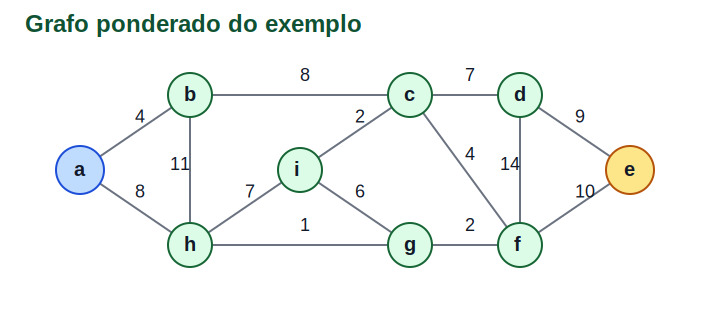

In [2]:
# 2) Plotagem do grafo em SVG para reforçar o entendimento visual.
# Custo desta célula (função): O(V + E), porque desenha todos os vértices e todas as arestas uma vez.

def desenhar_grafo_svg(grafo, posicoes, caminho=None, origem=None, destino=None):
    caminho = caminho or []
    arestas_caminho = {
        frozenset((u, v))
        for u, v in zip(caminho, caminho[1:])
    }

    arestas_desenhadas = set()
    elementos = [
        '<svg xmlns="http://www.w3.org/2000/svg" width="720" height="330" viewBox="0 0 720 330">',
        '<style>text { font-family: Arial, sans-serif; } .peso { font-size: 18px; fill: #111827; } .rotulo { font-size: 20px; font-weight: bold; fill: #111827; }</style>',
        '<rect width="100%" height="100%" fill="#ffffff" rx="18" />',
        '<text x="25" y="32" font-size="24" font-weight="bold" fill="#0f5132">Grafo ponderado do exemplo</text>',
    ]

    for u, vizinhos in grafo.items():
        x1, y1 = posicoes[u]
        for v, peso in vizinhos:
            chave = tuple(sorted((u, v)))
            if chave in arestas_desenhadas:
                continue
            arestas_desenhadas.add(chave)

            x2, y2 = posicoes[v]
            destaque = frozenset((u, v)) in arestas_caminho
            cor = '#dc2626' if destaque else '#6b7280'
            largura = 4 if destaque else 2
            elementos.append(
                f'<line x1="{x1}" y1="{y1}" x2="{x2}" y2="{y2}" stroke="{cor}" stroke-width="{largura}" />'
            )

            mx = (x1 + x2) / 2
            my = (y1 + y2) / 2
            if y1 == y2:
                my -= 14
            elif x1 == x2:
                mx -= 20
            else:
                my -= 10
            elementos.append(f'<text class="peso" x="{mx}" y="{my}">{peso}</text>')

    for vertice, (x, y) in posicoes.items():
        fill = '#dcfce7'
        stroke = '#166534'
        raio = 22
        if vertice == origem:
            fill = '#bfdbfe'
            stroke = '#1d4ed8'
            raio = 24
        elif vertice == destino:
            fill = '#fde68a'
            stroke = '#b45309'
            raio = 24
        elif vertice in caminho:
            fill = '#fecaca'
            stroke = '#dc2626'

        elementos.append(f'<circle cx="{x}" cy="{y}" r="{raio}" fill="{fill}" stroke="{stroke}" stroke-width="2" />')
        elementos.append(f'<text class="rotulo" x="{x - 6}" y="{y + 6}">{vertice}</text>')

    elementos.append('</svg>')
    return ''.join(elementos)


display(SVG(desenhar_grafo_svg(grafo, posicoes, origem=origem, destino=destino)))


## Etapa 3 — Inicialização conforme o pseudo código

O slide começa definindo todas as distâncias como infinito, todos os pais como `null` e a distância da origem como `0`. A função abaixo reproduz exatamente essa preparação inicial.


In [3]:
# 3) Inicialização do algoritmo exatamente como no pseudo código: distâncias infinitas, pais nulos e fila com a origem.
# Custo desta célula (função): O(V), pois percorre o conjunto de vértices uma vez.

def inicializar_dijkstra(grafo, origem):
    distancias = {vertice: inf for vertice in grafo}
    pais = {vertice: None for vertice in grafo}
    distancias[origem] = 0
    fila_prioridade = [(0, origem)]
    visitados = set()
    return distancias, pais, fila_prioridade, visitados


## Etapa 4 — Extração do vértice com menor distância

No laço principal, o algoritmo sempre escolhe o vértice não visitado com menor distância conhecida. Como o slide sugere o uso de uma **min-heap**, essa operação é implementada com fila de prioridade.


In [4]:
# 4) Extração do vértice com menor distância ainda não visitado.
# Custo desta célula (função): O(log V) por remoção válida da heap; entradas antigas são descartadas de forma amortizada.

def extrair_minimo(fila_prioridade, visitados):
    while fila_prioridade:
        distancia_atual, vertice = heappop(fila_prioridade)
        if vertice not in visitados:
            return distancia_atual, vertice
    return None, None


## Etapa 5 — Relaxamento das arestas

Depois de escolher o vértice atual `u`, o Dijkstra verifica se existe um caminho melhor para cada vizinho `v` passando por `u`. Esse processo é chamado de **relaxamento** e é o núcleo da atualização das menores distâncias.


In [5]:
# 5) Relaxamento das arestas: tenta melhorar a menor distância conhecida passando pelo vértice atual.
# Custo desta célula (função): O(log V) quando há atualização, por causa da inserção na heap; caso contrário, O(1).

def relaxar_aresta(u, v, peso, distancias, pais, fila_prioridade):
    nova_distancia = distancias[u] + peso
    if nova_distancia < distancias[v]:
        distancias[v] = nova_distancia
        pais[v] = u
        heappush(fila_prioridade, (nova_distancia, v))
        return True, nova_distancia
    return False, distancias[v]


## Etapa 6 — Laço principal do algoritmo

Agora unimos as etapas anteriores no mesmo fluxo descrito no slide: enquanto a fila não estiver vazia, extraímos o mínimo, percorremos os adjacentes e relaxamos as arestas. Também registramos um histórico para tornar a execução mais didática.


In [6]:
# 6) Laço principal do Dijkstra conforme o pseudo código do slide.
# Custo desta célula (função): O((V + E) log V) usando lista de adjacência e min-heap.

def dijkstra(grafo, origem):
    distancias, pais, fila_prioridade, visitados = inicializar_dijkstra(grafo, origem)
    historico = []

    while fila_prioridade:
        distancia_atual, u = extrair_minimo(fila_prioridade, visitados)
        if u is None:
            break

        visitados.add(u)
        atualizacoes = []

        for v, peso in grafo[u]:
            houve_melhoria, nova_distancia = relaxar_aresta(
                u, v, peso, distancias, pais, fila_prioridade
            )
            if houve_melhoria:
                atualizacoes.append(f"{v}: {nova_distancia} (pai={u})")

        historico.append(
            {
                'passo': len(historico) + 1,
                'vertice': u,
                'distancia_fixada': distancia_atual,
                'atualizacoes': ', '.join(atualizacoes) if atualizacoes else 'nenhuma atualização',
                'visitados': ', '.join(sorted(visitados)),
            }
        )

    return distancias, pais, historico


## Etapa 7 — Reconstrução do caminho mínimo

Além das distâncias, o algoritmo guarda o pai de cada vértice. Com esse vetor de predecessores, podemos reconstruir o menor caminho entre a origem e o destino ao final da execução.


In [7]:
# 7) Reconstrução do caminho mínimo a partir do vetor de pais.
# Custo desta célula (função): O(V) no pior caso, quando o caminho percorre todos os vértices.

def reconstruir_caminho(pais, origem, destino):
    caminho = []
    atual = destino

    while atual is not None:
        caminho.append(atual)
        atual = pais[atual]

    caminho.reverse()
    if not caminho or caminho[0] != origem:
        return []
    return caminho


## Etapa 8 — Execução do exemplo dos slides

Nesta etapa, o algoritmo é executado no grafo do enunciado. A saída mostra o menor caminho encontrado, as distâncias finais para todos os vértices e um resumo das iterações realizadas.


In [8]:
# 8) Execução do algoritmo no grafo do slide, exibindo distâncias finais e o passo a passo principal.
# Custo desta célula: O((V + E) log V) para executar o algoritmo; as tabelas HTML percorrem O(V) e O(V + E) dados já calculados.

distancias, pais, historico = dijkstra(grafo, origem)
caminho_minimo = reconstruir_caminho(pais, origem, destino)

linhas_distancias = ''.join(
    f'<tr><td style="padding:6px 10px;border:1px solid #d1d5db;">{vertice}</td><td style="padding:6px 10px;border:1px solid #d1d5db;">{distancia}</td><td style="padding:6px 10px;border:1px solid #d1d5db;">{pais[vertice]}</td></tr>'
    for vertice, distancia in sorted(distancias.items())
)

tabela_distancias = (
    f'<h3>Distâncias mínimas a partir de {origem}</h3>'
    '<table style="border-collapse:collapse;font-size:14px;">'
    '<tr style="background:#dcfce7;">'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">Vértice</th>'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">Distância</th>'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">Pai</th>'
    '</tr>'
    f'{linhas_distancias}'
    '</table>'
)

linhas_historico = ''.join(
    f'<tr><td style="padding:6px 10px;border:1px solid #d1d5db;">{item["passo"]}</td><td style="padding:6px 10px;border:1px solid #d1d5db;">{item["vertice"]}</td><td style="padding:6px 10px;border:1px solid #d1d5db;">{item["distancia_fixada"]}</td><td style="padding:6px 10px;border:1px solid #d1d5db;">{item["atualizacoes"]}</td><td style="padding:6px 10px;border:1px solid #d1d5db;">{item["visitados"]}</td></tr>'
    for item in historico
)

tabela_historico = (
    '<h3>Resumo das iterações do Dijkstra</h3>'
    '<table style="border-collapse:collapse;font-size:14px;">'
    '<tr style="background:#dbeafe;">'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">Passo</th>'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">u extraído</th>'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">Distância fixada</th>'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">Atualizações</th>'
    '<th style="padding:6px 10px;border:1px solid #d1d5db;">Visitados</th>'
    '</tr>'
    f'{linhas_historico}'
    '</table>'
)

resumo_execucao = (
    f"<div style='padding:12px 14px;border-left:5px solid #166534;background:#f0fdf4;margin:10px 0 18px 0;'>"
    f"<b>Menor caminho de {origem} até {destino}:</b> {' → '.join(caminho_minimo)}<br>"
    f"<b>Custo total:</b> {distancias[destino]}"
    '</div>'
)

display(HTML(resumo_execucao))
display(HTML(tabela_distancias))
display(HTML(tabela_historico))


Vértice,Distância,Pai
a,0,None
b,4,a
c,12,b
d,19,c
e,21,f
f,11,g
g,9,h
h,8,a
i,14,c


Passo,u extraído,Distância fixada,Atualizações,Visitados
1,a,0,"b: 4 (pai=a), h: 8 (pai=a)",a
2,b,4,c: 12 (pai=b),"a, b"
3,h,8,"g: 9 (pai=h), i: 15 (pai=h)","a, b, h"
4,g,9,f: 11 (pai=g),"a, b, g, h"
5,f,11,"d: 25 (pai=f), e: 21 (pai=f)","a, b, f, g, h"
6,c,12,"d: 19 (pai=c), i: 14 (pai=c)","a, b, c, f, g, h"
7,i,14,nenhuma atualização,"a, b, c, f, g, h, i"
8,d,19,nenhuma atualização,"a, b, c, d, f, g, h, i"
9,e,21,nenhuma atualização,"a, b, c, d, e, f, g, h, i"


## Etapa 9 — Visualização do menor caminho encontrado

Por fim, o mesmo grafo é redesenhado com destaque para o caminho mínimo calculado. Isso facilita comparar a resposta final com os pesos do enunciado.


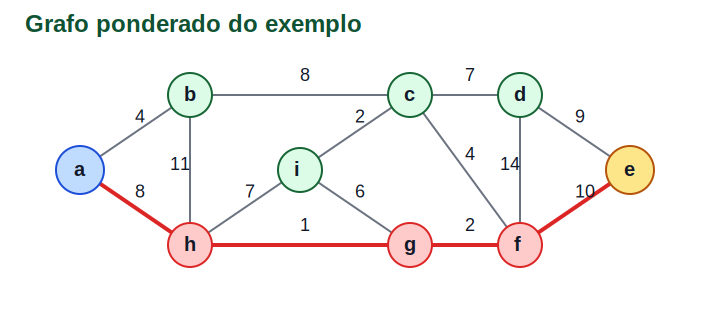

In [9]:
# 9) Visualização final do menor caminho encontrado no grafo.
# Custo desta célula: O(V + E), pois a renderização em SVG percorre novamente vértices e arestas.

display(SVG(desenhar_grafo_svg(
    grafo,
    posicoes,
    caminho=caminho_minimo,
    origem=origem,
    destino=destino,
)))


## Estatística final de custo computacional

Considerando a implementação com **lista de adjacência** para o grafo e **min-heap** para a fila de prioridade, os custos das partes principais ficam:

- **Modelagem do grafo:** `O(V + E)`
- **Inicialização das estruturas:** `O(V)`
- **Extração do mínimo:** `O(log V)` por operação válida
- **Relaxamento de aresta:** `O(log V)` quando ocorre atualização
- **Reconstrução do caminho final:** `O(V)` no pior caso
- **Plotagens em SVG/HTML:** `O(V + E)` por renderização

### Custo total dominante

O custo dominante do notebook é o do algoritmo de Dijkstra:

\[
O((V + E) \log V)
\]

Como o slide destaca o uso de **lista** para o grafo e **min-heap** para a fila `q`, essa é a complexidade total esperada para a busca do menor caminho. As células de visualização e apresentação não alteram essa ordem dominante; elas apenas acrescentam uma sobrecarga linear para fins didáticos.
